# Import Libraries

In [1]:
from fatloss_env import FatLossEnv
from callbacks import TqdmCallback
from stable_baselines3 import PPO, DQN

## Check Environment

In [2]:
print("--- Sanity Check: Random Agent Simulation ---")
env = FatLossEnv()
obs, info = env.reset()

print(f"Starting Client: {info['True Weight']:.1f}kg | Fat: {info['True Fat']:.1f}%\n")

# Run 5 completely random days
for i in range(5):
    random_action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(random_action)
    print(f"Day {i+1} | Action: {env.action_names[random_action]} | Weight: {info['True Weight']:.1f}kg")

print("\n✅ Sanity check passed! Environment is ready for AI training.")

--- Sanity Check: Random Agent Simulation ---
Starting Client: 77.2kg | Fat: 36.8%

Day 1 | Action: 6-Moderate + High Exertion | Weight: 77.2kg
Day 2 | Action: 8-Maintenance + Light Activity | Weight: 77.2kg
Day 3 | Action: 8-Maintenance + Light Activity | Weight: 77.2kg
Day 4 | Action: 8-Maintenance + Light Activity | Weight: 77.2kg
Day 5 | Action: 8-Maintenance + Light Activity | Weight: 77.2kg

✅ Sanity check passed! Environment is ready for AI training.


# Deep-Q Network

## Default Baseline Training

In [3]:
import os
from stable_baselines3.common.monitor import Monitor
from stable_baselines3 import DQN
from callbacks import TqdmCallback
from fatloss_env import FatLossEnv

print("--- Training DEFAULT DQN Agent ---")

os.makedirs("logs/default_dqn", exist_ok=True)
train_env_default = Monitor(FatLossEnv(), "logs/default_dqn")

default_dqn = DQN(
"MlpPolicy", 
train_env_default, 
    learning_rate=1e-3, 
    buffer_size=50000, 
    learning_starts=1000, 
    target_update_interval=500,
    verbose=0
)

total_steps = 100000
callback_default = TqdmCallback(total_timesteps=total_steps, desc="Default DQN Training")
default_dqn.learn(total_timesteps=total_steps, callback=callback_default)

# 4. Save the model
default_dqn.save("baseline_dqn_model")
print("\n✅ Default DQN Trained and Saved Successfully!")

--- Training DEFAULT DQN Agent ---


Default DQN Training: 100%|██████████| 100000/100000 [01:31<00:00, 1093.51it/s]


✅ Default DQN Trained and Saved Successfully!


📊 Generating Learning Curve for Default DQN...


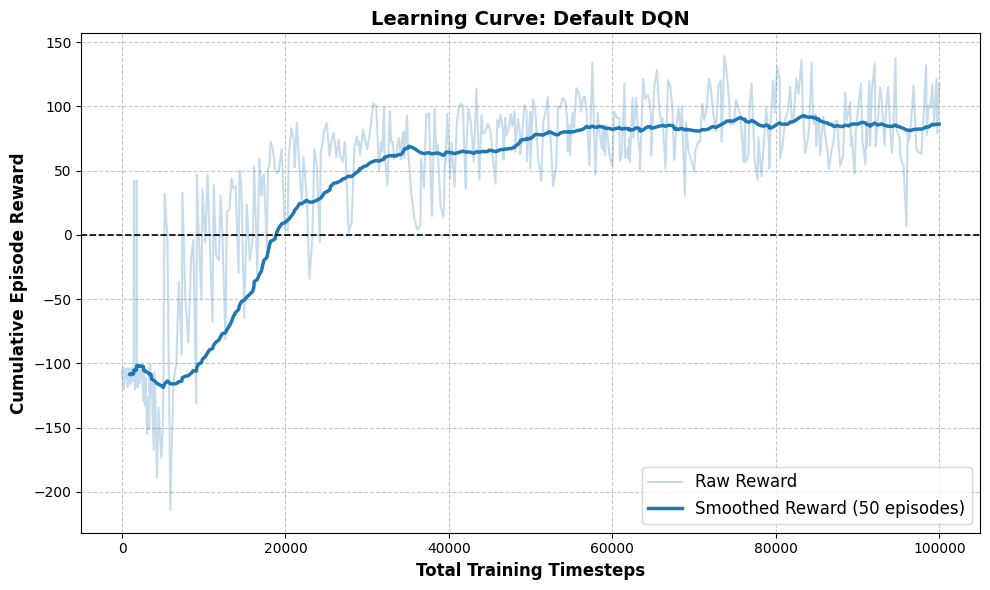

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

print("📊 Generating Learning Curve for Default DQN...")

# Stable Baselines3 monitor.csv files have a JSON dictionary on the very first line.
# We use skiprows=1 to skip that header and read the actual CSV data.
log_file = "logs/default_dqn/monitor.csv"

try:
    # --- 1. Load and Process the Data ---
    df = pd.read_csv(log_file, skiprows=1)
    
    # Calculate the cumulative timesteps (adding up episode lengths)
    df['cumulative_steps'] = df['l'].cumsum()
    
    # Calculate a rolling average (smoothing) to clearly see the learning trend
    # A window of 50 means it averages the rewards over 50 episodes
    df['smoothed_reward'] = df['r'].rolling(window=50).mean()

    # --- 2. Plot the Graph ---
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot the raw episodic rewards in the background (lightly transparent)
    ax.plot(df['cumulative_steps'], df['r'], color='#1f77b4', alpha=0.25, label='Raw Reward')
    
    # Plot the smoothed line on top
    ax.plot(df['cumulative_steps'], df['smoothed_reward'], color='#1f77b4', linewidth=2.5, label='Smoothed Reward (50 episodes)')

    # --- 3. Formatting ---
    ax.set_title("Learning Curve: Default DQN", fontsize=14, fontweight='bold')
    ax.set_xlabel("Total Training Timesteps", fontsize=12, fontweight='bold')
    ax.set_ylabel("Cumulative Episode Reward", fontsize=12, fontweight='bold')
    
    # Add a horizontal line at 0 for reference (optional, helps see when it becomes "profitable")
    ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
    
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(fontsize=12, loc='lower right')

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"❌ Error: Could not find {log_file}. Make sure the training cell finished running successfully!")

## Optimize Hyperparameters Training

In [5]:
import optuna
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy
from fatloss_env import FatLossEnv

def optimize_dqn(trial):
    return {
        'learning_rate': trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True),
        'gamma': trial.suggest_float("gamma", 0.8, 0.9999),
        'buffer_size': trial.suggest_categorical("buffer_size", [10000, 50000, 100000]),
        'exploration_fraction': trial.suggest_float("exploration_fraction", 0.1, 0.5),
    }

def objective(trial):
    params = optimize_dqn(trial)
    env = FatLossEnv()
    # Use a smaller number of steps for the study to save time
    model = DQN("MlpPolicy", env, verbose=0, **params)
    model.learn(total_timesteps=300000)
    mean_reward, _ = evaluate_policy(model, env, n_eval_episodes=5)
    return mean_reward

dqn_study = optuna.create_study(direction="maximize")
dqn_study.optimize(objective, n_trials=10) 

# This defines the variable your later cells are looking for
best_dqn_params = dqn_study.best_params 
print(f"Best params found: {best_dqn_params}")

c:\Users\USER\Desktop\ML\env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-16 23:56:01,842] A new study created in memory with name: no-name-2128932f-6600-467e-ba79-b55c32fb6053
c:\Users\USER\Desktop\ML\env\lib\site-packages\stable_baselines3\common\evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(
[I 2026-04-16 23:59:31,452] Trial 0 finished with value: 107.5223338060081 and parameters: {'learning_rate': 0.0018322144236157353, 'gamma': 0.8089503680989113, 'buffer_size': 10000, 'exploration_fraction': 0.3586828818910107}. Best is trial 0 with value: 107.5223338060081.
[I

Best params found: {'learning_rate': 0.0018322144236157353, 'gamma': 0.8089503680989113, 'buffer_size': 10000, 'exploration_fraction': 0.3586828818910107}


In [6]:
# --- 3. TRAIN HPO DQN ---
print("\n--- Training HPO DQN Agent ---")

# Create the directory for the HPO logs
os.makedirs("logs/hpo_dqn", exist_ok=True)
train_env_hpo = Monitor(FatLossEnv(), "logs/hpo_dqn") # THIS CREATES THE CSV!

# Inject the BEST parameters found by Optuna into the final model
hpo_dqn = DQN(
    "MlpPolicy", 
    train_env_hpo, 
    learning_rate=best_dqn_params['learning_rate'],
    buffer_size=best_dqn_params['buffer_size'],
    exploration_fraction=best_dqn_params['exploration_fraction'],
    gamma=best_dqn_params['gamma'],
    learning_starts=1000,
    target_update_interval=500,
    verbose=0
)

callback_hpo = TqdmCallback(total_timesteps=total_steps, desc="HPO DQN Training")
hpo_dqn.learn(total_timesteps=total_steps, callback=callback_hpo)
hpo_dqn.save("dqn_model")

print("\n✅ HPO DQN Trained and Saved Successfully!")


--- Training HPO DQN Agent ---


HPO DQN Training: 100%|██████████| 100000/100000 [01:10<00:00, 1410.35it/s]


✅ HPO DQN Trained and Saved Successfully!


## Learning Curve of DQN

📊 Generating Learning Curves for Default vs. HPO DQN...


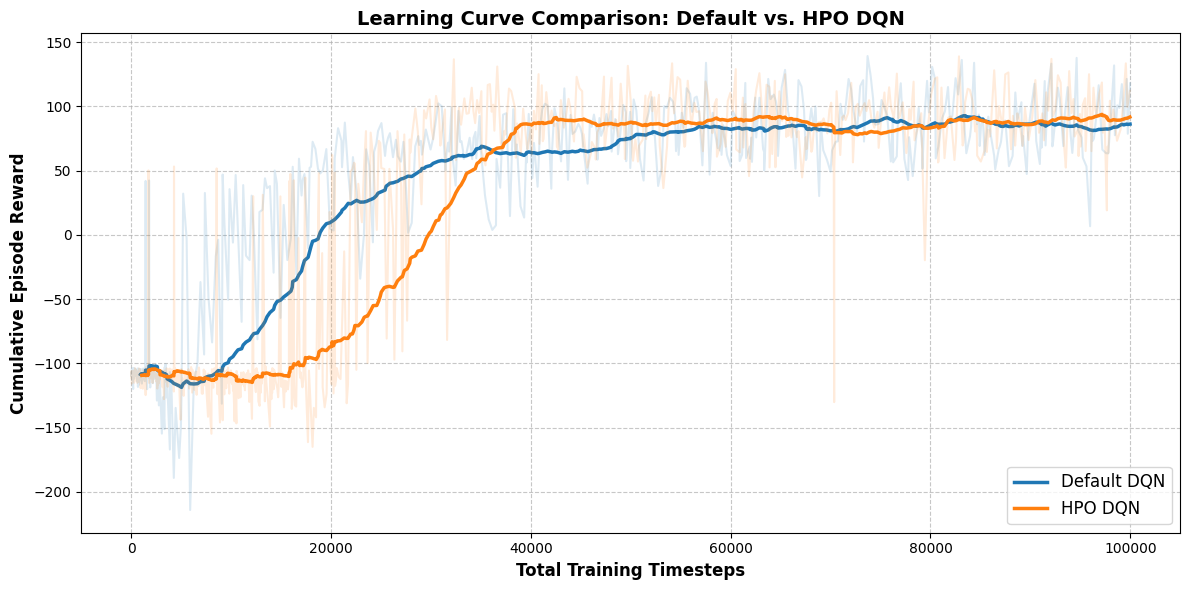

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

print("📊 Generating Learning Curves for Default vs. HPO DQN...")

# --- 1. Load the Default DQN Logs ---
df_default = pd.read_csv("logs/default_dqn/monitor.csv", skiprows=1)
df_default['cumulative_steps'] = df_default['l'].cumsum()
# Smooth the line (rolling average of 50 episodes) to make it readable
df_default['smoothed_reward'] = df_default['r'].rolling(window=50).mean()

# --- 2. Load the HPO DQN Logs ---
df_hpo = pd.read_csv("logs/hpo_dqn/monitor.csv", skiprows=1)
df_hpo['cumulative_steps'] = df_hpo['l'].cumsum()
df_hpo['smoothed_reward'] = df_hpo['r'].rolling(window=50).mean()

# --- 3. Plot the Comparison Graph ---
fig, ax = plt.subplots(figsize=(12, 6))

# Plot Default DQN (Blue)
# Raw data lightly in the background, clean smoothed line on top
ax.plot(df_default['cumulative_steps'], df_default['r'], color='#1f77b4', alpha=0.15)
ax.plot(df_default['cumulative_steps'], df_default['smoothed_reward'], 
        color='#1f77b4', linewidth=2.5, label='Default DQN')

# Plot HPO DQN (Orange)
ax.plot(df_hpo['cumulative_steps'], df_hpo['r'], color='#ff7f0e', alpha=0.15)
ax.plot(df_hpo['cumulative_steps'], df_hpo['smoothed_reward'], 
        color='#ff7f0e', linewidth=2.5, label='HPO DQN')

# Graph 
ax.set_title("Learning Curve Comparison: Default vs. HPO DQN", fontsize=14, fontweight='bold')
ax.set_xlabel("Total Training Timesteps", fontsize=12, fontweight='bold')
ax.set_ylabel("Cumulative Episode Reward", fontsize=12, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(fontsize=12, loc='lower right')

plt.tight_layout()
plt.show()

## Testing DQN Agent

🚀 Running Head-to-Head Evaluation over 20 random clients...

--- Episode 1/20 : HPO Agent ---
CLIENT PROFILE: 38-year-old Male, 176.9cm
START: True Weight=97.9kg | True Fat=49.7%
Day 001 | HPO Chose Action: 1 | Scale Weight: 97.8kg | True Fat: 49.7% | Sleep: 7.7h
Day 002 | HPO Chose Action: 1 | Scale Weight: 97.7kg | True Fat: 49.6% | Sleep: 7.4h
Day 003 | HPO Chose Action: 4 | Scale Weight: 97.6kg | True Fat: 49.6% | Sleep: 7.4h
Day 004 | HPO Chose Action: 0 | Scale Weight: 97.5kg | True Fat: 49.5% | Sleep: 7.9h
Day 005 | HPO Chose Action: 4 | Scale Weight: 97.5kg | True Fat: 49.5% | Sleep: 7.9h
Day 006 | HPO Chose Action: 1 | Scale Weight: 97.4kg | True Fat: 49.4% | Sleep: 7.6h
Day 007 | HPO Chose Action: 4 | Scale Weight: 97.3kg | True Fat: 49.4% | Sleep: 7.6h
Day 008 | HPO Chose Action: 0 | Scale Weight: 97.2kg | True Fat: 49.4% | Sleep: 8.1h
Day 009 | HPO Chose Action: 4 | Scale Weight: 97.1kg | True Fat: 49.3% | Sleep: 8.1h
Day 010 | HPO Chose Action: 1 | Scale Weight: 97.0kg | T

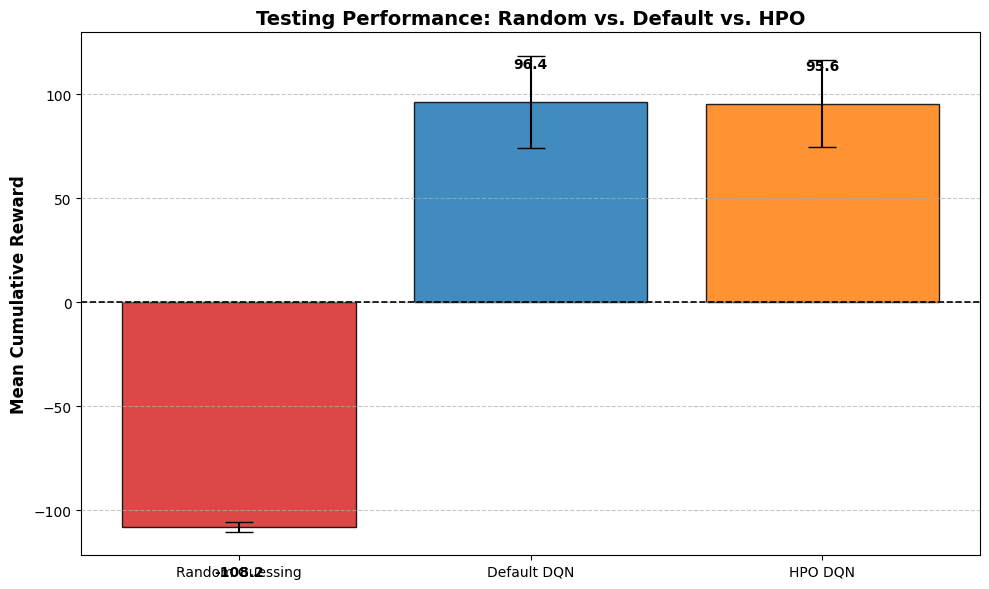

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import DQN
from fatloss_env import FatLossEnv

def evaluate_all_agents(n_episodes=20):
    print(f"🚀 Running Head-to-Head Evaluation over {n_episodes} random clients...")
    env = FatLossEnv()
    
    # Load your two trained models
    default_model = DQN.load("baseline_dqn_model")
    hpo_model = DQN.load("dqn_model")
    
    random_rewards = []
    default_rewards = []
    hpo_rewards = []
    
    for i in range(n_episodes):
        # --- 1. Test the Random Baseline ---
        obs, info = env.reset()
        total_random = 0
        done = False
        while not done:
            action = env.action_space.sample() 
            obs, reward, terminated, truncated, info = env.step(action)
            total_random += reward
            done = terminated or truncated
        random_rewards.append(total_random)
        
        # --- 2. Test the Default DQN ---
        obs, info = env.reset() # Reset so it gets a fresh client
        total_default = 0
        done = False
        while not done:
            action, _ = default_model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            total_default += reward
            done = terminated or truncated
        default_rewards.append(total_default)

        # --- 3. Test the HPO DQN (With Client Profile & Logging) ---
        obs, info = env.reset()
        
        # Extract demographic data
        gender_str = "Male" if obs[3] == 1.0 else "Female"
        age = int(obs[4])
        height = obs[5]
        
        print(f"\n--- Episode {i+1}/{n_episodes} : HPO Agent ---")
        print(f"CLIENT PROFILE: {age}-year-old {gender_str}, {height:.1f}cm")
        print(f"START: True Weight={info['True Weight']:.1f}kg | True Fat={info['True Fat']:.1f}%")

        total_hpo = 0
        done = False
        
        while not done:
            action, _ = hpo_model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            total_hpo += reward
            done = terminated or truncated
            
            # Print daily logs ONLY for the first episode to avoid crashing the notebook output
            if i == 0:
                print(f"Day {env.current_step:03d} | HPO Chose Action: {action} | "
                      f"Scale Weight: {obs[0]:.1f}kg | True Fat: {obs[1]:.1f}% | Sleep: {obs[2]:.1f}h")

        print(f"Game Over at Day {env.current_step}.")
        print(f"Final True Fat: {info['True Fat']:.1f}% | Total Cumulative Reward: {total_hpo:.2f}")

        # Check Win/Loss Outcome
        if terminated:
            if info['True Fat'] <= env.target_fat:
                print("RESULT: SUCCESS! The HPO agent hit the Jackpot!")
            else:
                print("RESULT: FAILED. The HPO agent crashed the user.")
        elif truncated:
            print("RESULT: TIME OUT. The HPO agent survived 365 days but didn't reach the fat goal.")
            
        hpo_rewards.append(total_hpo)

    # --- Calculate the Results ---
    mean_random = np.mean(random_rewards)
    mean_default = np.mean(default_rewards)
    mean_hpo = np.mean(hpo_rewards)
    
    print("\n" + "="*50)
    print("🏆 FINAL EVALUATION RESULTS 🏆")
    print("="*50)
    print(f"Random Guessing : {mean_random:.2f} ± {np.std(random_rewards):.2f}")
    print(f"Default DQN     : {mean_default:.2f} ± {np.std(default_rewards):.2f}")
    print(f"HPO DQN         : {mean_hpo:.2f} ± {np.std(hpo_rewards):.2f}")
    
    # --- Plot the Comparison ---
    print("\n📊 Generating Comparison Graph...")
    fig, ax = plt.subplots(figsize=(10, 6))
    
    labels = ['Random Guessing', 'Default DQN', 'HPO DQN']
    means = [mean_random, mean_default, mean_hpo]
    stds = [np.std(random_rewards), np.std(default_rewards), np.std(hpo_rewards)]
    colors = ['#d62728', '#1f77b4', '#ff7f0e']
    
    bars = ax.bar(labels, means, yerr=stds, capsize=10, color=colors, alpha=0.85, edgecolor='black')
    
    ax.set_ylabel('Mean Cumulative Reward', fontweight='bold', fontsize=12)
    ax.set_title('Testing Performance: Random vs. Default vs. HPO', fontweight='bold', fontsize=14)
    ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add the exact numbers on top of the bars for easy reading
    for bar in bars:
        yval = bar.get_height()
        # Adjust text placement based on whether the value is positive or negative
        offset = 15 if yval >= 0 else -25
        ax.text(bar.get_x() + bar.get_width()/2, yval + offset, f'{yval:.1f}', 
                ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Execute the test
evaluate_all_agents()

# Proximal Policy Optimization

## Default Baseline Training


In [9]:
import os
import optuna
import pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3 import PPO
from callbacks import TqdmCallback
from fatloss_env import FatLossEnv

# ==========================================
# 1. TRAIN DEFAULT PPO (BASELINE)
# ==========================================
print("--- Training DEFAULT PPO Agent ---")

# Create a specific folder for default logs
os.makedirs("logs/default_ppo", exist_ok=True)
train_env_default_ppo = Monitor(FatLossEnv(), "logs/default_ppo") # Creates monitor.csv

default_ppo = PPO("MlpPolicy", train_env_default_ppo, verbose=0)

total_steps_ppo = 400000
callback_default_ppo = TqdmCallback(total_timesteps=total_steps_ppo, desc="Default PPO Training")
default_ppo.learn(total_timesteps=total_steps_ppo, callback=callback_default_ppo)
default_ppo.save("baseline_ppo_model")

print("\n✅ Default PPO Trained and Saved Successfully!")

--- Training DEFAULT PPO Agent ---


Default PPO Training: 401408it [09:12, 726.00it/s]                             


✅ Default PPO Trained and Saved Successfully!


📊 Generating Learning Curve for Default DQN...


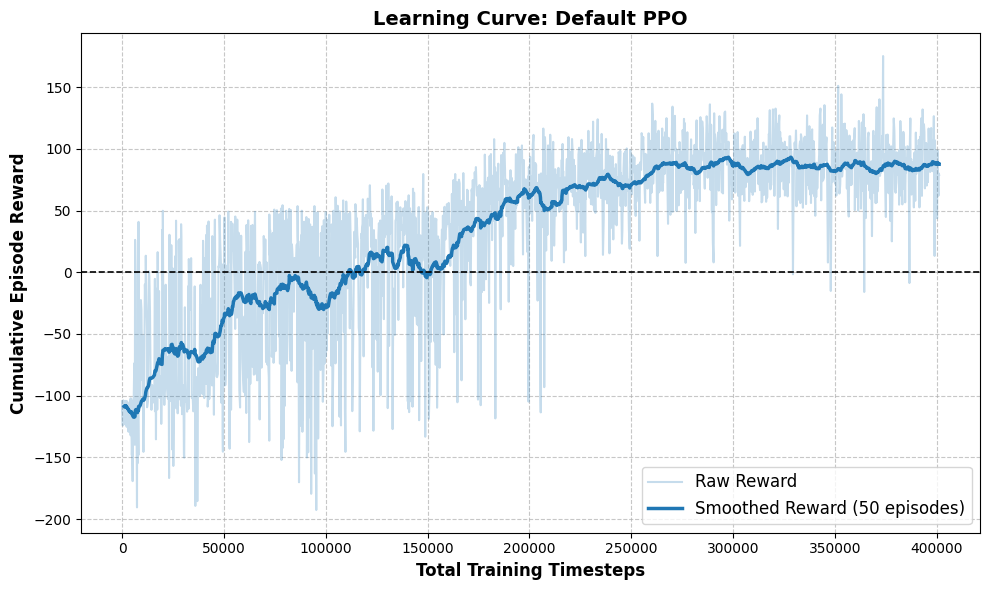

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

print("📊 Generating Learning Curve for Default DQN...")

# Stable Baselines3 monitor.csv files have a JSON dictionary on the very first line.
# We use skiprows=1 to skip that header and read the actual CSV data.
log_file = "logs/default_ppo/monitor.csv"

try:
    # --- 1. Load and Process the Data ---
    df = pd.read_csv(log_file, skiprows=1)
    
    # Calculate the cumulative timesteps (adding up episode lengths)
    df['cumulative_steps'] = df['l'].cumsum()
    
    # Calculate a rolling average (smoothing) to clearly see the learning trend
    # A window of 50 means it averages the rewards over 50 episodes
    df['smoothed_reward'] = df['r'].rolling(window=50).mean()

    # --- 2. Plot the Graph ---
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot the raw episodic rewards in the background (lightly transparent)
    ax.plot(df['cumulative_steps'], df['r'], color='#1f77b4', alpha=0.25, label='Raw Reward')
    
    # Plot the smoothed line on top
    ax.plot(df['cumulative_steps'], df['smoothed_reward'], color='#1f77b4', linewidth=2.5, label='Smoothed Reward (50 episodes)')

    # --- 3. Formatting ---
    ax.set_title("Learning Curve: Default PPO", fontsize=14, fontweight='bold')
    ax.set_xlabel("Total Training Timesteps", fontsize=12, fontweight='bold')
    ax.set_ylabel("Cumulative Episode Reward", fontsize=12, fontweight='bold')
    
    # Add a horizontal line at 0 for reference (optional, helps see when it becomes "profitable")
    ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
    
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(fontsize=12, loc='lower right')

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"❌ Error: Could not find {log_file}. Make sure the training cell finished running successfully!")

## Optimize Hyperparameters Training

In [14]:
# ==========================================
# 2. RUN OPTUNA HYPERPARAMETER SEARCH
# ==========================================
print("\n--- Phase 1: Running PPO Optuna Search (10 Trials) ---")

def optimize_ppo(trial):
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    gamma = trial.suggest_float("gamma", 0.8, 0.9999)
    ent_coef = trial.suggest_float("ent_coef", 0.0001, 0.1, log=True)
    n_steps = trial.suggest_categorical("n_steps", [1024, 2048, 4096])
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])

    env = FatLossEnv()
    model = PPO(
        "MlpPolicy", 
        env, 
        learning_rate=learning_rate, 
        gamma=gamma, 
        ent_coef=ent_coef, 
        n_steps=n_steps,
        batch_size=batch_size,
        verbose=0
    )
    
    model.learn(total_timesteps=300000)
    mean_reward, _ = evaluate_policy(model, env, n_eval_episodes=5)
    return mean_reward

ppo_study = optuna.create_study(direction="maximize")
ppo_study.optimize(optimize_ppo, n_trials=10)

print("\n🏆 BEST PPO PARAMETERS FOUND:")
best_ppo_params = ppo_study.best_params
for key, value in best_ppo_params.items():
    print(f" - {key}: {value}")

[I 2026-04-17 02:18:38,394] A new study created in memory with name: no-name-1fa4b339-212a-492b-843c-16372319ae06



--- Phase 1: Running PPO Optuna Search (10 Trials) ---


[I 2026-04-17 02:23:15,688] Trial 0 finished with value: -2681.1363572097384 and parameters: {'learning_rate': 0.0020497964281519124, 'gamma': 0.8330882113486965, 'ent_coef': 0.0006451151132077387, 'n_steps': 4096, 'batch_size': 128}. Best is trial 0 with value: -2681.1363572097384.
[I 2026-04-17 02:26:31,551] Trial 1 finished with value: -6779.760939478874 and parameters: {'learning_rate': 0.00010306150315043528, 'gamma': 0.9342305148851373, 'ent_coef': 0.001910136085187916, 'n_steps': 1024, 'batch_size': 256}. Best is trial 0 with value: -2681.1363572097384.
[I 2026-04-17 02:30:16,871] Trial 2 finished with value: 20.545267621567472 and parameters: {'learning_rate': 0.0005642262211198981, 'gamma': 0.9543982027939508, 'ent_coef': 0.01085870243091744, 'n_steps': 1024, 'batch_size': 128}. Best is trial 2 with value: 20.545267621567472.
[I 2026-04-17 02:33:29,324] Trial 3 finished with value: -4687.130052586179 and parameters: {'learning_rate': 0.0033560975408365393, 'gamma': 0.887074927


🏆 BEST PPO PARAMETERS FOUND:
 - learning_rate: 0.0005099166242697651
 - gamma: 0.8540529666754383
 - ent_coef: 0.002109217622211901
 - n_steps: 2048
 - batch_size: 128


In [15]:
# ==========================================
# 3. TRAIN HPO PPO AGENT (WITH MONITOR)
# ==========================================
print("\n--- Phase 2: Initiating Tuned PPO Agent Training ---")

# FIX: Create a specific folder for HPO logs and wrap the env in a Monitor
os.makedirs("logs/hpo_ppo", exist_ok=True)
train_env_hpo_ppo = Monitor(FatLossEnv(), "logs/hpo_ppo") # Creates monitor.csv

hpo_ppo_model = PPO(
    "MlpPolicy", 
    train_env_hpo_ppo, # Use the monitored environment here!
    learning_rate=best_ppo_params['learning_rate'],
    gamma=best_ppo_params['gamma'],
    ent_coef=best_ppo_params['ent_coef'],
    n_steps=best_ppo_params['n_steps'],
    batch_size=best_ppo_params['batch_size'],
    verbose=0
)

ppo_callback = TqdmCallback(total_timesteps=total_steps_ppo, desc="HPO PPO Training")
hpo_ppo_model.learn(total_timesteps=total_steps_ppo, callback=ppo_callback)
hpo_ppo_model.save("ppo_model")

print("\n✅ Tuned PPO Training Complete & Model Saved!")


--- Phase 2: Initiating Tuned PPO Agent Training ---


HPO PPO Training: 401408it [05:12, 1284.22it/s]                            


✅ Tuned PPO Training Complete & Model Saved!



📊 Generating Learning Curves for Default vs. HPO PPO...


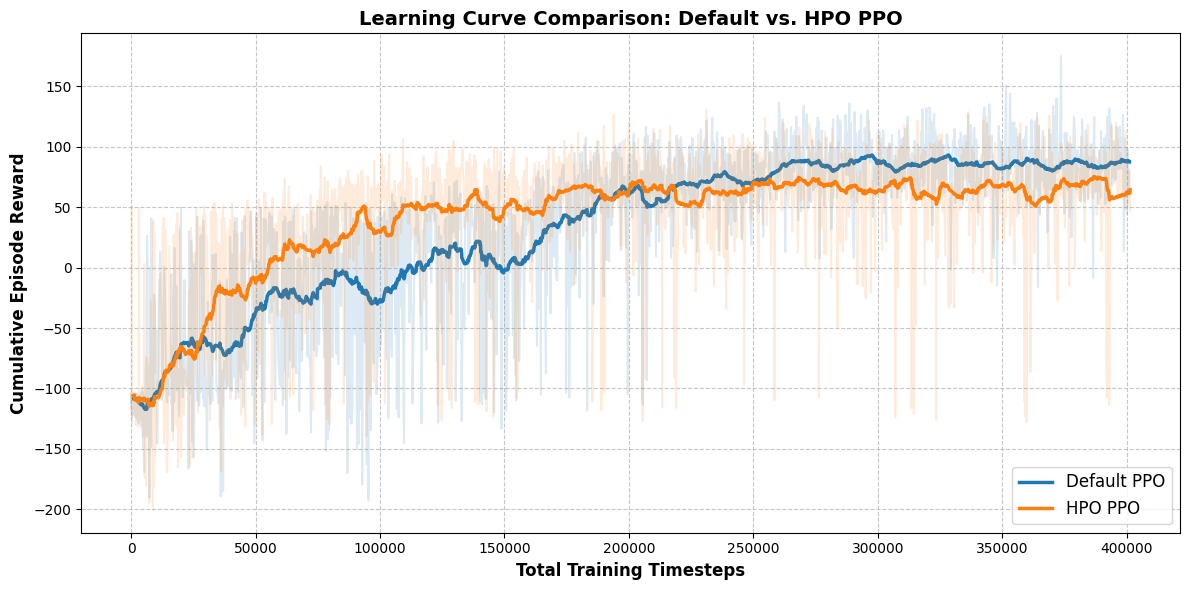

In [16]:
# ==========================================
# 4. PLOT PPO LEARNING CURVES
# ==========================================
print("\n📊 Generating Learning Curves for Default vs. HPO PPO...")

# Load the Default PPO Logs
df_default_ppo = pd.read_csv("logs/default_ppo/monitor.csv", skiprows=1)
df_default_ppo['cumulative_steps'] = df_default_ppo['l'].cumsum()
df_default_ppo['smoothed_reward'] = df_default_ppo['r'].rolling(window=50).mean()

# Load the HPO PPO Logs
df_hpo_ppo = pd.read_csv("logs/hpo_ppo/monitor.csv", skiprows=1)
df_hpo_ppo['cumulative_steps'] = df_hpo_ppo['l'].cumsum()
df_hpo_ppo['smoothed_reward'] = df_hpo_ppo['r'].rolling(window=50).mean()

# Plot the Comparison Graph
fig, ax = plt.subplots(figsize=(12, 6))

# Plot Default PPO (Blue)
ax.plot(df_default_ppo['cumulative_steps'], df_default_ppo['r'], color='#1f77b4', alpha=0.15)
ax.plot(df_default_ppo['cumulative_steps'], df_default_ppo['smoothed_reward'], 
        color='#1f77b4', linewidth=2.5, label='Default PPO')

# Plot HPO PPO (Orange)
ax.plot(df_hpo_ppo['cumulative_steps'], df_hpo_ppo['r'], color='#ff7f0e', alpha=0.15)
ax.plot(df_hpo_ppo['cumulative_steps'], df_hpo_ppo['smoothed_reward'], 
        color='#ff7f0e', linewidth=2.5, label='HPO PPO')

# Graph Formatting
ax.set_title("Learning Curve Comparison: Default vs. HPO PPO", fontsize=14, fontweight='bold')
ax.set_xlabel("Total Training Timesteps", fontsize=12, fontweight='bold')
ax.set_ylabel("Cumulative Episode Reward", fontsize=12, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(fontsize=12, loc='lower right')

plt.tight_layout()
plt.show()

## Testing PPO Agent 

🚀 Running PPO Head-to-Head Evaluation over 20 random clients...

--- Episode 1/20 : HPO PPO Agent ---
CLIENT PROFILE: 38-year-old Female, 158.8cm
START: True Weight=77.3kg | True Fat=48.6%
Day 001 | HPO Chose Action: 1 | Scale Weight: 77.2kg | True Fat: 48.5% | Sleep: 7.7h
Day 002 | HPO Chose Action: 1 | Scale Weight: 77.1kg | True Fat: 48.5% | Sleep: 7.4h
Day 003 | HPO Chose Action: 3 | Scale Weight: 77.1kg | True Fat: 48.4% | Sleep: 7.9h
Day 004 | HPO Chose Action: 1 | Scale Weight: 77.0kg | True Fat: 48.4% | Sleep: 7.6h
Day 005 | HPO Chose Action: 3 | Scale Weight: 76.9kg | True Fat: 48.3% | Sleep: 8.1h
Day 006 | HPO Chose Action: 1 | Scale Weight: 76.8kg | True Fat: 48.3% | Sleep: 7.8h
Day 007 | HPO Chose Action: 3 | Scale Weight: 76.8kg | True Fat: 48.2% | Sleep: 8.3h
Day 008 | HPO Chose Action: 1 | Scale Weight: 76.7kg | True Fat: 48.2% | Sleep: 8.0h
Day 009 | HPO Chose Action: 3 | Scale Weight: 76.6kg | True Fat: 48.1% | Sleep: 8.5h
Day 010 | HPO Chose Action: 1 | Scale Weight: 

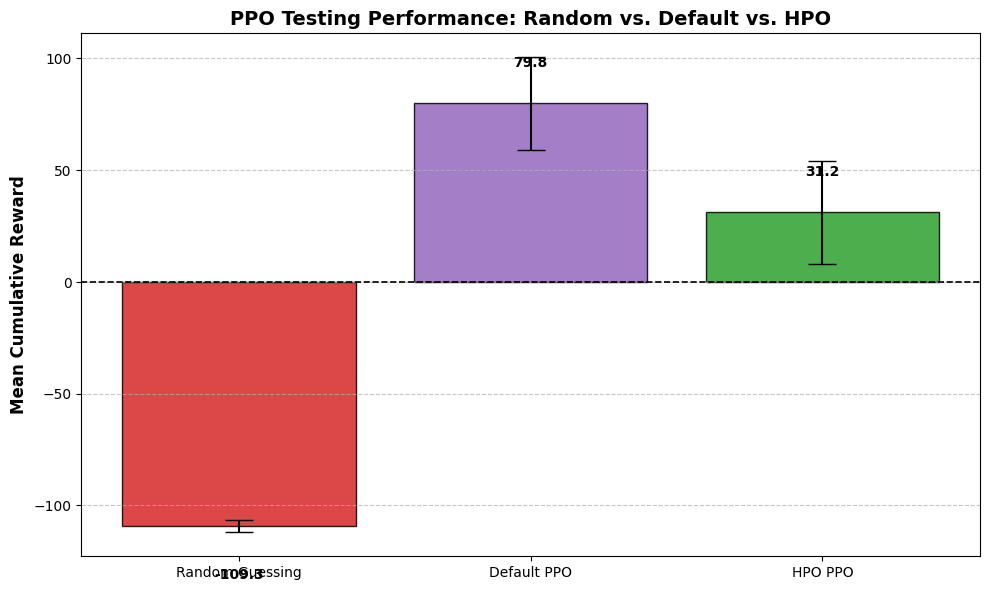

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from fatloss_env import FatLossEnv

def evaluate_all_ppo_agents(n_episodes=20):
    print(f"🚀 Running PPO Head-to-Head Evaluation over {n_episodes} random clients...")
    env = FatLossEnv()
    
    # Load your two trained models (Make sure these names match your saved files!)
    try:
        default_model = PPO.load("baseline_ppo_model")
        hpo_model = PPO.load("ppo_model")
    except FileNotFoundError:
        print("ERROR: Could not find the saved models. Make sure 'baseline_ppo_model.zip' and 'ppo_model.zip' exist.")
        return
    
    random_rewards = []
    default_rewards = []
    hpo_rewards = []
    
    for i in range(n_episodes):
        # --- 1. Test the Random Baseline ---
        obs, info = env.reset()
        total_random = 0
        done = False
        while not done:
            action = env.action_space.sample() 
            obs, reward, terminated, truncated, info = env.step(action)
            total_random += reward
            done = terminated or truncated
        random_rewards.append(total_random)
        
        # --- 2. Test the Default PPO ---
        obs, info = env.reset() # Reset so it gets a fresh client
        total_default = 0
        done = False
        while not done:
            action, _ = default_model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            total_default += reward
            done = terminated or truncated
        default_rewards.append(total_default)

        # --- 3. Test the HPO PPO (With Client Profile & Logging) ---
        obs, info = env.reset()
        
        # Extract demographic data
        gender_str = "Male" if obs[3] == 1.0 else "Female"
        age = int(obs[4])
        height = obs[5]
        
        print(f"\n--- Episode {i+1}/{n_episodes} : HPO PPO Agent ---")
        print(f"CLIENT PROFILE: {age}-year-old {gender_str}, {height:.1f}cm")
        print(f"START: True Weight={info['True Weight']:.1f}kg | True Fat={info['True Fat']:.1f}%")

        total_hpo = 0
        done = False
        
        while not done:
            action, _ = hpo_model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            total_hpo += reward
            done = terminated or truncated
            
            # Print daily logs ONLY for the first episode to avoid crashing the notebook output
            if i == 0:
                print(f"Day {env.current_step:03d} | HPO Chose Action: {action} | "
                      f"Scale Weight: {obs[0]:.1f}kg | True Fat: {obs[1]:.1f}% | Sleep: {obs[2]:.1f}h")

        print(f"Game Over at Day {env.current_step}.")
        print(f"Final True Fat: {info['True Fat']:.1f}% | Total Cumulative Reward: {total_hpo:.2f}")

        # Check Win/Loss Outcome
        if terminated:
            if info['True Fat'] <= env.target_fat:
                print("RESULT: SUCCESS! The HPO agent hit the Jackpot!")
            else:
                print("RESULT: FAILED. The HPO agent crashed the user.")
        elif truncated:
            print("RESULT: TIME OUT. The HPO agent survived 365 days but didn't reach the fat goal.")
            
        hpo_rewards.append(total_hpo)

    # --- Calculate the Results ---
    mean_random = np.mean(random_rewards)
    mean_default = np.mean(default_rewards)
    mean_hpo = np.mean(hpo_rewards)
    
    print("\n" + "="*50)
    print("🏆 FINAL PPO EVALUATION RESULTS 🏆")
    print("="*50)
    print(f"Random Guessing : {mean_random:.2f} ± {np.std(random_rewards):.2f}")
    print(f"Default PPO     : {mean_default:.2f} ± {np.std(default_rewards):.2f}")
    print(f"HPO PPO         : {mean_hpo:.2f} ± {np.std(hpo_rewards):.2f}")
    
    # --- Plot the Comparison ---
    print("\n📊 Generating Comparison Graph...")
    fig, ax = plt.subplots(figsize=(10, 6))
    
    labels = ['Random Guessing', 'Default PPO', 'HPO PPO']
    means = [mean_random, mean_default, mean_hpo]
    stds = [np.std(random_rewards), np.std(default_rewards), np.std(hpo_rewards)]
    
    # Using a purple color scheme to differentiate PPO charts from DQN (which used blue/orange)
    colors = ['#d62728', '#9467bd', '#2ca02c'] 
    
    bars = ax.bar(labels, means, yerr=stds, capsize=10, color=colors, alpha=0.85, edgecolor='black')
    
    ax.set_ylabel('Mean Cumulative Reward', fontweight='bold', fontsize=12)
    ax.set_title('PPO Testing Performance: Random vs. Default vs. HPO', fontweight='bold', fontsize=14)
    ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add the exact numbers on top of the bars for easy reading
    for bar in bars:
        yval = bar.get_height()
        offset = 15 if yval >= 0 else -25
        ax.text(bar.get_x() + bar.get_width()/2, yval + offset, f'{yval:.1f}', 
                ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Execute the test
evaluate_all_ppo_agents()

# Evaluation

In [18]:
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3 import PPO, DQN
from fatloss_env import FatLossEnv

print("📊 Evaluating Models Head-to-Head (20 Episodes Each)...")

# 1. We must wrap the environment in a Monitor for evaluate_policy to work
eval_env = Monitor(FatLossEnv())

# 2. Load both models
ppo_eval_model = PPO.load("ppo_model")
dqn_eval_model = DQN.load("dqn_model")

# 3. Run the strict evaluation
ppo_mean_reward, ppo_std_reward = evaluate_policy(ppo_eval_model, eval_env, n_eval_episodes=20)
dqn_mean_reward, dqn_std_reward = evaluate_policy(dqn_eval_model, eval_env, n_eval_episodes=20)

# 4. Print the final results
print("-" * 35)
print("🏆 FINAL PERFORMANCE RESULTS 🏆")
print("-" * 35)
print(f"PPO Mean Reward: {ppo_mean_reward:.2f} +/- {ppo_std_reward:.2f}")
print(f"DQN Mean Reward: {dqn_mean_reward:.2f} +/- {dqn_std_reward:.2f}")

if ppo_mean_reward > dqn_mean_reward:
    print("\nConclusion: PPO achieved a higher mean reward and is the superior algorithm for this task.")
else:
    print("\nConclusion: DQN achieved a higher mean reward and is the superior algorithm for this task.")

📊 Evaluating Models Head-to-Head (20 Episodes Each)...
-----------------------------------
🏆 FINAL PERFORMANCE RESULTS 🏆
-----------------------------------
PPO Mean Reward: 39.66 +/- 20.28
DQN Mean Reward: 102.48 +/- 19.53

Conclusion: DQN achieved a higher mean reward and is the superior algorithm for this task.


📊 Evaluating Models for Performance Comparison...
Running evaluation over 20 random clients. Please wait...
----------------------------------------
🏆 PPO Mean Reward: 36.73 (± 19.52)
🏆 DQN Mean Reward: 96.64 (± 20.79)
----------------------------------------


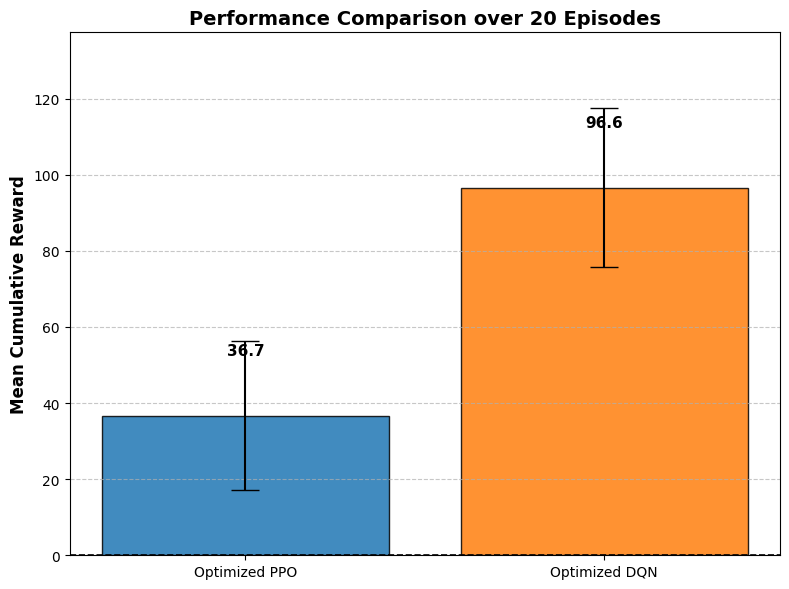

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO, DQN
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from fatloss_env import FatLossEnv

print("📊 Evaluating Models for Performance Comparison...")

# 1. Wrap the environment to track metrics properly
eval_env = Monitor(FatLossEnv())

# 2. Load the best optimized models
# (Make sure these names match exactly what you saved in Phase 2)
ppo_model = PPO.load("ppo_model")
dqn_model = DQN.load("dqn_model")

# 3. Evaluate both models 
# We test on 20 different random clients to get a scientifically fair average
n_episodes = 20
print(f"Running evaluation over {n_episodes} random clients. Please wait...")

ppo_mean, ppo_std = evaluate_policy(ppo_model, eval_env, n_eval_episodes=n_episodes)
dqn_mean, dqn_std = evaluate_policy(dqn_model, eval_env, n_eval_episodes=n_episodes)

print("-" * 40)
print(f"🏆 PPO Mean Reward: {ppo_mean:.2f} (± {ppo_std:.2f})")
print(f"🏆 DQN Mean Reward: {dqn_mean:.2f} (± {dqn_std:.2f})")
print("-" * 40)

# 4. Plot the Comparison Graph
models = ['Optimized PPO', 'Optimized DQN']
means = [ppo_mean, dqn_mean]
errors = [ppo_std, dqn_std]

fig, ax = plt.subplots(figsize=(8, 6))

# Create the bars with error bars (capsize adds the little flat lines on the error bars)
bars = ax.bar(models, means, yerr=errors, capsize=10, 
              color=['#1f77b4', '#ff7f0e'], alpha=0.85, edgecolor='black')

# Add the exact numbers on top of the bars
for bar in bars:
    yval = bar.get_height()
    # Adjust text position based on whether the score is positive or negative
    offset = 15 if yval >= 0 else -25
    ax.text(bar.get_x() + bar.get_width()/2, yval + offset, 
            f'{yval:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Formatting the graph to look academic and professional
ax.set_ylabel('Mean Cumulative Reward', fontsize=12, fontweight='bold')
ax.set_title(f'Performance Comparison over {n_episodes} Episodes', fontsize=14, fontweight='bold')
ax.axhline(0, color='black', linewidth=1.2, linestyle='--') # Adds a baseline at zero
ax.grid(axis='y', linestyle='--', alpha=0.7)
max_y = max(means) + max(errors)
ax.set_ylim(0, max_y + 20)

# Display the graph
plt.tight_layout()
plt.show()

In [20]:
from stable_baselines3 import PPO, DQN
from fatloss_env import FatLossEnv

print("📊 Calculating AI Success Rate (Testing 100 Random Clients)...")

# 1. Choose which model to test (Change to "dqn_model" to test DQN)
model = PPO.load("ppo_model")
test_env = FatLossEnv()

total_episodes = 100
success_count = 0

for episode in range(total_episodes):
    # Load a completely new random person
    obs, info = test_env.reset()
    
    terminated = False
    truncated = False
    
    # Run the simulation for this person until the year is over or they hit the goal
    while not terminated and not truncated:
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = test_env.step(action)
    
    # Check if the AI won (If True Fat is less than or equal to Target Fat)
    if terminated and info['True Fat'] <= test_env.target_fat:
        success_count += 1

# 2. Calculate the Final Percentage
success_rate = (success_count / total_episodes) * 100

print("-" * 40)
print(f"🏆 FINAL SUCCESS RATE: {success_rate:.1f}%")
print(f"The AI successfully reached the target fat goal for {success_count} out of {total_episodes} clients.")
print("-" * 40)

📊 Calculating AI Success Rate (Testing 100 Random Clients)...
----------------------------------------
🏆 FINAL SUCCESS RATE: 55.0%
The AI successfully reached the target fat goal for 55 out of 100 clients.
----------------------------------------


In [21]:
import pandas as pd
from stable_baselines3 import PPO, DQN
from fatloss_env import FatLossEnv

def evaluate_comprehensive_metrics(model_name, model_path, n_episodes=100):
    env = FatLossEnv()
    
    if model_name == "PPO":
        model = PPO.load(model_path)
    else:
        model = DQN.load(model_path)
        
    successes = 0
    crashes = 0
    total_rewards = []
    days_taken = []
    
    for _ in range(n_episodes):
        obs, info = env.reset()
        terminated = truncated = False
        ep_reward = 0
        
        while not terminated and not truncated:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            ep_reward += reward
            
        total_rewards.append(ep_reward)
        
        # Check outcomes
        if terminated:
            if info['True Fat'] <= env.target_fat:
                successes += 1
                days_taken.append(info['Step']) # Only count days for successful runs
            else:
                crashes += 1 # Hit the -100 safety penalty
                
    # Calculate final metrics
    avg_reward = sum(total_rewards) / n_episodes
    success_rate = (successes / n_episodes) * 100
    crash_rate = (crashes / n_episodes) * 100
    avg_days = sum(days_taken) / len(days_taken) if days_taken else 365
    
    return {
        "Model": model_name,
        "Mean Reward": f"{avg_reward:.2f}",
        "Success Rate": f"{success_rate:.1f}%",
        "Crash Rate (Safety)": f"{crash_rate:.1f}%",
        "Avg Days to Goal": f"{avg_days:.1f}"
    }

print("🚀 Running comprehensive evaluation over 100 episodes. Please wait...")

# Run the tests
ppo_results = evaluate_comprehensive_metrics("PPO", "ppo_model")
dqn_results = evaluate_comprehensive_metrics("DQN", "dqn_model")

# Create a beautiful Pandas DataFrame table
df_eval = pd.DataFrame([ppo_results, dqn_results])
df_eval.set_index("Model", inplace=True)

print("\n" + "="*50)
print("🏆 COMPREHENSIVE PERFORMANCE TABLE 🏆")
print("="*50)
print(df_eval.to_markdown())

🚀 Running comprehensive evaluation over 100 episodes. Please wait...

🏆 COMPREHENSIVE PERFORMANCE TABLE 🏆


ImportError: Missing optional dependency 'tabulate'.  Use pip or conda to install tabulate.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from fatloss_env import FatLossEnv

def compare_with_random_baseline(model_path="best_ppo_model", n_episodes=20):
    print(f"🚀 Running Baseline Comparison over {n_episodes} random clients...")
    env = FatLossEnv()
    model = PPO.load(model_path)
    
    random_rewards = []
    trained_rewards = []
    
    for i in range(n_episodes):
        # --- 1. Test the Random Baseline ---
        obs, info = env.reset()
        total_random = 0
        done = False
        while not done:
            # Agent guesses randomly
            action = env.action_space.sample() 
            obs, reward, terminated, truncated, info = env.step(action)
            total_random += reward
            done = terminated or truncated
        random_rewards.append(total_random)
        
        # --- 2. Test the Trained PPO Agent (on the exact same starting rules) ---
        obs, info = env.reset()
        total_trained = 0
        done = False
        while not done:
            # Agent uses its learned intelligence
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            total_trained += reward
            done = terminated or truncated
        trained_rewards.append(total_trained)

    # --- 3. Calculate and Print the Results ---
    mean_random = np.mean(random_rewards)
    mean_trained = np.mean(trained_rewards)
    
    print("\n" + "="*50)
    print("🏆 RANDOM BASELINE vs. TRAINED PPO 🏆")
    print("="*50)
    print(f"Random Guessing Agent : {mean_random:.2f} ± {np.std(random_rewards):.2f}")
    print(f"Trained PPO Agent     : {mean_trained:.2f} ± {np.std(trained_rewards):.2f}")
    
    if abs(mean_random) > 0:
        improvement = ((mean_trained - mean_random) / abs(mean_random)) * 100
        print(f"Performance Improvement: +{improvement:.1f}%")
        
    # --- 4. Plot the Comparison ---
    fig, ax = plt.subplots(figsize=(8, 6))
    bars = ax.bar(['Random Guessing', 'Trained PPO'], 
                  [mean_random, mean_trained], 
                  yerr=[np.std(random_rewards), np.std(trained_rewards)], 
                  capsize=10, color=['#d62728', '#1f77b4'], alpha=0.85, edgecolor='black')
    
    ax.set_ylabel('Mean Cumulative Reward', fontweight='bold')
    ax.set_title('Trained Intelligence vs. Random Actions', fontweight='bold', fontsize=14)
    ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Run the function
compare_with_random_baseline()